# S16 – CLIP-поиск по собственному набору изображений

В этом ноутбуке делаем следующий шаг после базового знакомства с CLIP:  
не просто сравниваем отдельные пары «текст ↔ изображение», а собираем полноценный **поисковый мультимодальный pipeline**.

Главная идея такая:

1. собираем локальный набор изображений;
2. считаем для него `image embeddings`;
3. строим компактный индекс в виде матрицы признаков;
4. подаём текстовый запрос;
5. получаем **top-k** наиболее подходящих изображений.

Это уже очень похоже на реальный сценарий:

- поиск картинок по текстовому описанию;
- мультимодальный просмотр коллекций;
- быстрый baseline для контент-поиска;
- первый шаг к image retrieval и visual search.

Чтобы ноутбук был воспроизводимым, ниже создадим **свой мини-датасет изображений**  
из локально сохранённого поднабора **CIFAR-10**.  
При желании этот же pipeline легко заменить на собственную папку с фотографиями или иллюстрациями.


## 0. План

К концу ноутбука надо уметь:

1. Подготавливать локальный каталог изображений для retrieval-задачи.
2. Считать и сохранять `image embeddings` для всей галереи.
3. Выполнять text-to-image поиск по косинусному сходству.
4. Визуализировать `top-k` результатов по текстовому запросу.
5. Сравнивать разные формулировки запросов.
6. Делать батчевый прогон по нескольким запросам и собирать сводную таблицу.
7. Считать простейшие retrieval-метрики: `Recall@1`, `Recall@3` и `Recall@5`.
8. Реализовывать базовый image-to-image retrieval в том же embedding-пространстве.


## 1. Импорты и общие настройки

Ниже снова подключаем CLIP, фиксируем `seed`, выбираем устройство и настраиваем вывод.

> Предполагается, что в окружении уже доступны `torch`, `transformers`, `torchvision`, `pillow`, `matplotlib`, `pandas` и `numpy`.


In [1]:

# Базовые библиотеки для локальной галереи, retrieval и визуализации.
import os
import random
from pathlib import Path
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from PIL import Image
from torchvision.datasets import CIFAR10
from transformers import CLIPModel, CLIPProcessor

pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 220)
pd.set_option("display.precision", 4)

os.environ["TOKENIZERS_PARALLELISM"] = "false"

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())


Torch: 2.10.0+cu128
CUDA available: True


In [2]:

# Фиксируем seed, определяем устройство и загружаем CLIP.
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Устройство:", DEVICE)

MODEL_NAME = "openai/clip-vit-base-patch32"

processor = CLIPProcessor.from_pretrained(MODEL_NAME)
clip_model = CLIPModel.from_pretrained(MODEL_NAME).to(DEVICE)
clip_model.eval()

print("Загружена модель:", MODEL_NAME)


Устройство: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Загружена модель: openai/clip-vit-base-patch32


## 2. Подготовка собственного мини-датасета изображений

Ниже соберём локальную папку `s16_clip_gallery` и сохраним туда небольшой набор изображений.

Это полезно по двум причинам:

- retrieval будет работать уже не с объектами в памяти, а с **реальной файловой галереей**;
- затем эту папку можно заменить на собственный набор изображений без изменения основной логики.

Для галереи возьмём 7 классов:

- `airplane`
- `bird`
- `cat`
- `dog`
- `horse`
- `ship`
- `truck`

Сохраним по 10 изображений каждого класса.


In [3]:

CIFAR_ROOT = Path("data")
GALLERY_DIR = Path("s16_clip_gallery")
GALLERY_DIR.mkdir(parents=True, exist_ok=True)

cifar_test = CIFAR10(root=CIFAR_ROOT, train=False, download=True)
class_names = cifar_test.classes
selected_classes = ["airplane", "bird", "cat", "dog", "horse", "ship", "truck"]
target_per_class = 10

gallery_records: List[Dict[str, str]] = []
counts = {cls: 0 for cls in selected_classes}

for image, label_id in cifar_test:
    class_name = class_names[label_id]
    if class_name not in selected_classes:
        continue
    if counts[class_name] >= target_per_class:
        continue

    file_name = f"{class_name}_{counts[class_name]:02d}.png"
    image_path = GALLERY_DIR / file_name
    image.save(image_path)

    gallery_records.append(
        {
            "image_id": file_name.replace(".png", ""),
            "image_path": str(image_path),
            "class_name": class_name,
        }
    )
    counts[class_name] += 1

    if all(count >= target_per_class for count in counts.values()):
        break

gallery_df = pd.DataFrame(gallery_records)
gallery_df.head()



  0%|          | 0.00/170M [00:00<?, ?B/s]
  0%|          | 32.8k/170M [00:00<17:30, 162kB/s]
  0%|          | 65.5k/170M [00:00<18:02, 157kB/s]
  0%|          | 98.3k/170M [00:00<18:06, 157kB/s]
  0%|          | 229k/170M [00:00<08:20, 340kB/s] 
  0%|          | 459k/170M [00:01<04:46, 592kB/s]
  0%|          | 655k/170M [00:01<03:19, 850kB/s]
  0%|          | 852k/170M [00:01<02:36, 1.09MB/s]
  1%|          | 1.05M/170M [00:01<02:12, 1.28MB/s]
  1%|          | 1.28M/170M [00:01<01:55, 1.46MB/s]
  1%|          | 1.47M/170M [00:01<01:47, 1.58MB/s]
  1%|          | 1.67M/170M [00:01<01:41, 1.66MB/s]
  1%|          | 1.87M/170M [00:01<01:37, 1.74MB/s]
  1%|          | 2.10M/170M [00:01<01:32, 1.81MB/s]
  1%|▏         | 2.29M/170M [00:02<01:34, 1.78MB/s]
  1%|▏         | 2.49M/170M [00:02<01:33, 1.79MB/s]
  2%|▏         | 2.69M/170M [00:02<01:34, 1.77MB/s]
  3%|▎         | 4.78M/170M [00:02<00:24, 6.71MB/s]
  3%|▎         | 5.44M/170M [00:02<00:29, 5.65MB/s]
  4%|▍         | 7.11M/170M [

,image_id,image_path,class_name
0,cat_00,s16_clip_gallery/cat_00.png,cat
1,ship_00,s16_clip_gallery/ship_00.png,ship
2,ship_01,s16_clip_gallery/ship_01.png,ship
3,airplane_00,s16_clip_gallery/airplane_00.png,airplane
4,cat_01,s16_clip_gallery/cat_01.png,cat


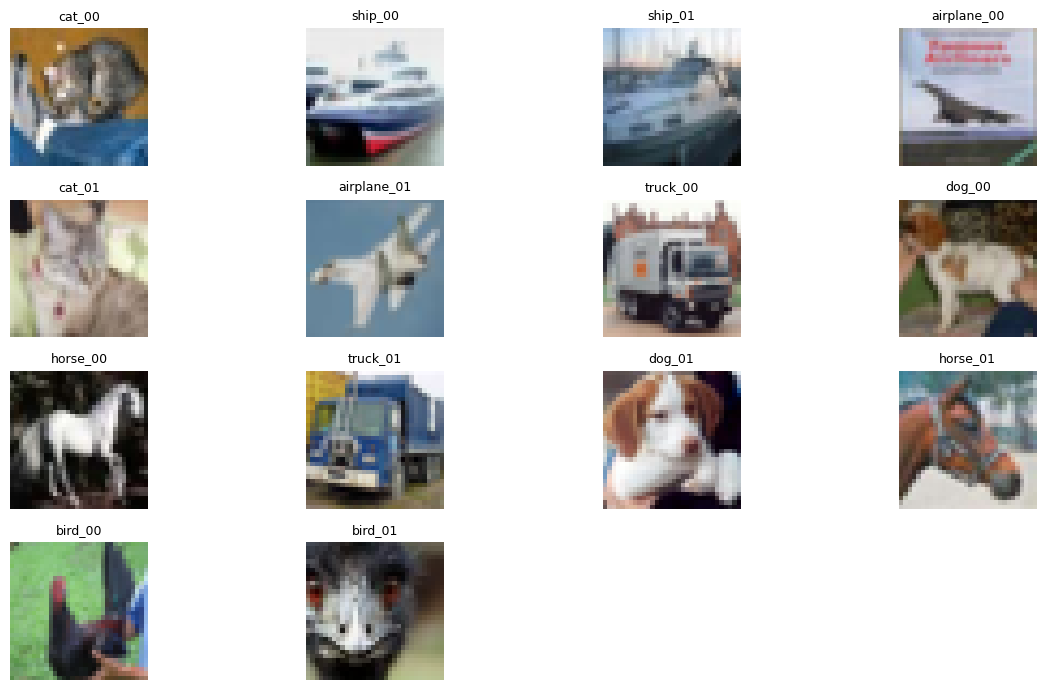

In [4]:

def load_gallery_images(df: pd.DataFrame) -> List[Image.Image]:
    return [Image.open(path).convert("RGB") for path in df["image_path"]]


def plot_results_grid(images: List[Image.Image], titles: List[str], cols: int = 5, figsize: Tuple[int, int] = (14, 6)) -> None:
    rows = int(np.ceil(len(images) / cols))
    plt.figure(figsize=figsize)

    for idx, (img, title) in enumerate(zip(images, titles), start=1):
        ax = plt.subplot(rows, cols, idx)
        ax.imshow(img)
        ax.set_title(title, fontsize=9)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


preview_df = gallery_df.groupby("class_name", group_keys=False).head(2).reset_index(drop=True)
plot_results_grid(
    images=load_gallery_images(preview_df),
    titles=preview_df["image_id"].tolist(),
    cols=4,
    figsize=(12, 7),
)


## 3. Индексация изображений: считаем `image embeddings`

Теперь у нас есть локальная галерея.  
Следующий шаг – превратить её в компактный индекс.

В простейшем варианте индекс состоит из двух частей:

- таблица метаданных (`image_id`, путь к файлу, класс и т.д.);
- матрица `image embeddings`.

Для небольшого датасета этого уже достаточно, чтобы выполнять поиск по косинусному сходству.


In [5]:

def l2_normalize(tensor: torch.Tensor) -> torch.Tensor:
    return tensor / tensor.norm(dim=-1, keepdim=True)


def encode_images(images: List[Image.Image]) -> torch.Tensor:
    inputs = processor(images=images, return_tensors="pt")
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

    with torch.no_grad():
        # В transformers 5.x get_image_features возвращает BaseModelOutputWithPooling;
        # спроецированные признаки (после visual_projection) лежат в .pooler_output.
        image_features = clip_model.get_image_features(**inputs).pooler_output

    return l2_normalize(image_features).cpu()


def encode_texts(texts: List[str]) -> torch.Tensor:
    inputs = processor(text=texts, return_tensors="pt", padding=True, truncation=True)
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

    with torch.no_grad():
        # Аналогично для текста: text_projection уже применён, результат в .pooler_output.
        text_features = clip_model.get_text_features(**inputs).pooler_output

    return l2_normalize(text_features).cpu()


In [6]:

gallery_images = load_gallery_images(gallery_df)
gallery_embeddings = encode_images(gallery_images)

print("Размер gallery_embeddings:", tuple(gallery_embeddings.shape))
print("Число изображений в галерее:", len(gallery_df))


Размер gallery_embeddings: (70, 512)
Число изображений в галерее: 70


## 4. Первый text-to-image поиск

Теперь реализуем поиск:

1. считаем embedding текстового запроса;
2. считаем similarity между запросом и всеми изображениями;
3. сортируем по убыванию score;
4. берём `top-k` результатов.

Это и есть базовый мультимодальный retrieval.


In [7]:

def search_by_text(query: str, top_k: int = 5) -> pd.DataFrame:
    text_embedding = encode_texts([query])
    scores = (gallery_embeddings @ text_embedding.T).flatten().numpy()

    ranked_df = gallery_df.copy()
    ranked_df["score"] = scores
    ranked_df = ranked_df.sort_values("score", ascending=False).reset_index(drop=True)
    ranked_df["rank"] = np.arange(1, len(ranked_df) + 1)

    return ranked_df.head(top_k)


query = "a photo of a cat"
top_results_df = search_by_text(query=query, top_k=5)
top_results_df


,image_id,image_path,class_name,score,rank
0,cat_02,s16_clip_gallery/cat_02.png,cat,0.2764,1
1,cat_09,s16_clip_gallery/cat_09.png,cat,0.2745,2
2,cat_04,s16_clip_gallery/cat_04.png,cat,0.2739,3
3,cat_07,s16_clip_gallery/cat_07.png,cat,0.2642,4
4,cat_01,s16_clip_gallery/cat_01.png,cat,0.2602,5


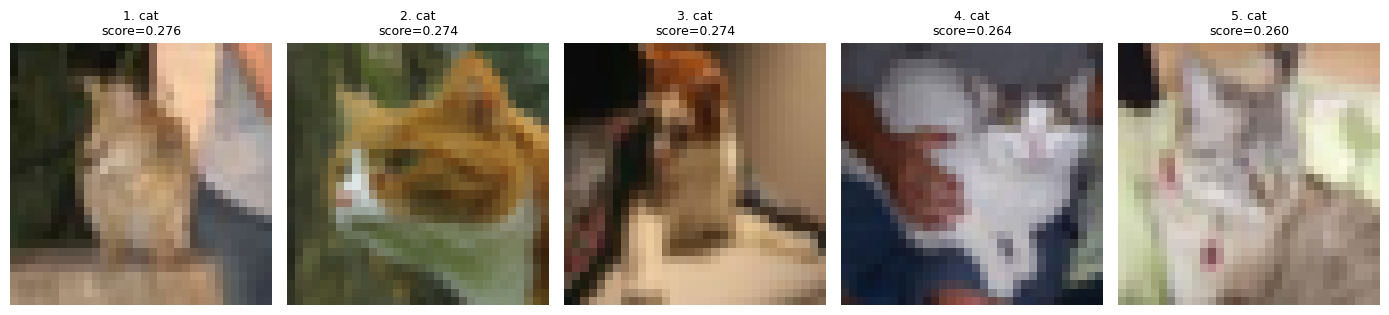

In [8]:

plot_results_grid(
    images=load_gallery_images(top_results_df),
    titles=[
        f"{row.rank}. {row.class_name}\nscore={row.score:.3f}"
        for row in top_results_df.itertuples()
    ],
    cols=5,
    figsize=(14, 4),
)


## 5. Визуализация нескольких запросов

Проверим retrieval не на одном запросе, а на нескольких.  
Это позволит увидеть, как CLIP ведёт себя на разных классах и разных формулировках.


QUERY: a photo of a ship


,rank,image_id,class_name,score
0,1,ship_07,ship,0.2757
1,2,ship_09,ship,0.2715
2,3,ship_04,ship,0.2680
3,4,ship_00,ship,0.2623
4,5,ship_05,ship,0.2511


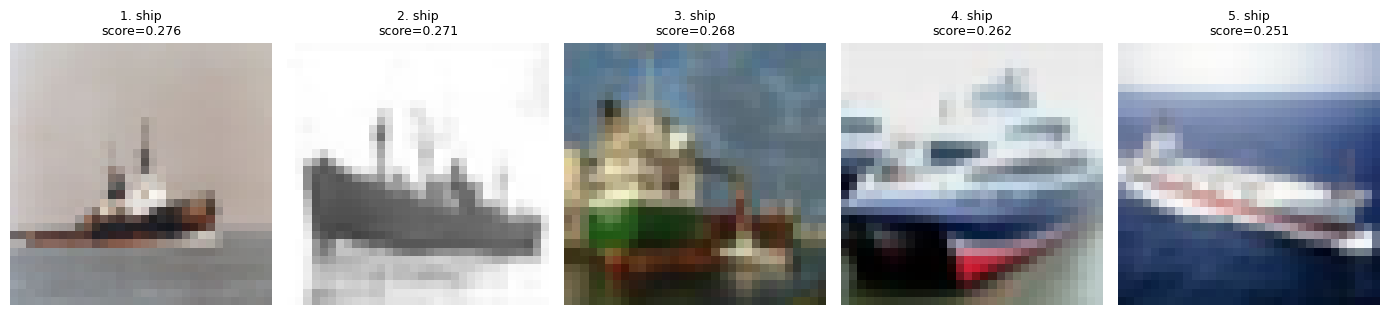

QUERY: a photo of a dog


,rank,image_id,class_name,score
0,1,dog_03,dog,0.2855
1,2,dog_02,dog,0.2698
2,3,dog_08,dog,0.2646
3,4,cat_04,cat,0.2619
4,5,dog_05,dog,0.2617


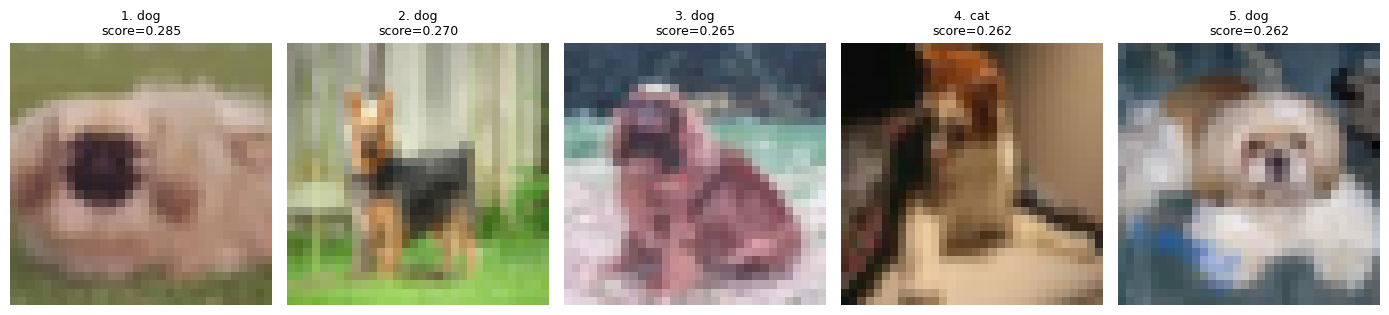

QUERY: a photo of a truck


,rank,image_id,class_name,score
0,1,truck_06,truck,0.2723
1,2,truck_01,truck,0.2657
2,3,truck_04,truck,0.2646
3,4,truck_09,truck,0.2567
4,5,truck_03,truck,0.2547


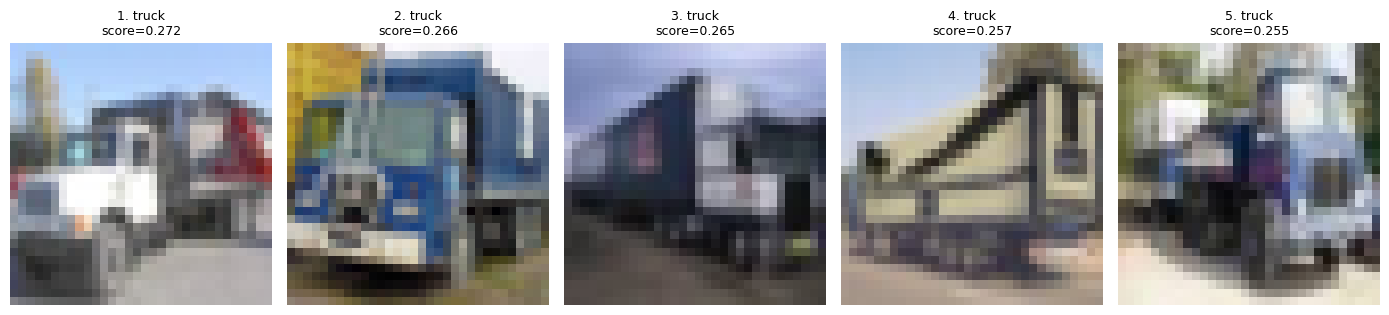

In [9]:

demo_queries = [
    "a photo of a ship",
    "a photo of a dog",
    "a photo of a truck",
]

for query in demo_queries:
    print("=" * 100)
    print("QUERY:", query)
    current_df = search_by_text(query=query, top_k=5)
    display(current_df[["rank", "image_id", "class_name", "score"]])

    plot_results_grid(
        images=load_gallery_images(current_df),
        titles=[
            f"{row.rank}. {row.class_name}\nscore={row.score:.3f}"
            for row in current_df.itertuples()
        ],
        cols=5,
        figsize=(14, 4),
    )


## 6. Как формулировка запроса влияет на retrieval

Как и в предыдущем ноутбуке, сравним несколько текстовых вариантов для одной и той же цели.  
Например, класс `ship` можно описать по-разному:

- `ship`
- `a photo of a ship`
- `a small ship on water`
- `a vehicle`
- `an animal`

Ниже посмотрим, как такие изменения влияют на выдачу и на top-1 результат.


In [10]:

ship_queries = [
    "ship",
    "a photo of a ship",
    "a small ship on water",
    "a vehicle",
    "an animal",
]

query_effect_records: List[Dict[str, object]] = []
for query in ship_queries:
    ranked_df = search_by_text(query=query, top_k=3)
    top1 = ranked_df.iloc[0]
    query_effect_records.append(
        {
            "query": query,
            "top1_image_id": top1["image_id"],
            "top1_class": top1["class_name"],
            "top1_score": top1["score"],
        }
    )

query_effect_df = pd.DataFrame(query_effect_records).sort_values("top1_score", ascending=False)
query_effect_df


,query,top1_image_id,top1_class,top1_score
1,a photo of a ship,ship_07,ship,0.2757
0,ship,ship_09,ship,0.2728
3,a vehicle,truck_06,truck,0.2659
2,a small ship on water,ship_04,ship,0.2656
4,an animal,dog_03,dog,0.2630


## 7. Поиск по нескольким запросам и сводная таблица

Для реального retrieval-пайплайна удобно запускать не один запрос, а пакет запросов  
и затем собирать общую таблицу вида:

- `query`
- `rank`
- `image_id`
- `class_name`
- `score`

Ниже именно такой батчевый прогон и сделаем.


In [11]:

batch_queries = [
    {"query": "a photo of an airplane", "target_class": "airplane"},
    {"query": "a photo of a bird", "target_class": "bird"},
    {"query": "a photo of a cat", "target_class": "cat"},
    {"query": "a photo of a dog", "target_class": "dog"},
    {"query": "a photo of a horse", "target_class": "horse"},
    {"query": "a photo of a ship", "target_class": "ship"},
    {"query": "a photo of a truck", "target_class": "truck"},
]

batch_records: List[Dict[str, object]] = []
for item in batch_queries:
    ranked_df = search_by_text(query=item["query"], top_k=5)
    for row in ranked_df.itertuples():
        batch_records.append(
            {
                "query": item["query"],
                "target_class": item["target_class"],
                "rank": row.rank,
                "image_id": row.image_id,
                "retrieved_class": row.class_name,
                "score": row.score,
            }
        )

batch_df = pd.DataFrame(batch_records)
batch_df.head(15)


,query,target_class,rank,image_id,retrieved_class,score
0,a photo of an airplane,airplane,1,airplane_07,airplane,0.2673
1,a photo of an airplane,airplane,2,airplane_04,airplane,0.2665
2,a photo of an airplane,airplane,3,airplane_08,airplane,0.2608
3,a photo of an airplane,airplane,4,airplane_01,airplane,0.2607
4,a photo of an airplane,airplane,5,airplane_09,airplane,0.2588
5,a photo of a bird,bird,1,bird_03,bird,0.2865
6,a photo of a bird,bird,2,bird_05,bird,0.2791
7,a photo of a bird,bird,3,bird_02,bird,0.2765
8,a photo of a bird,bird,4,bird_04,bird,0.2758
9,a photo of a bird,bird,5,bird_00,bird,0.2713


## 8. Простейшая оценка качества retrieval

Для учебного примера не будем усложнять оценку.  
Здесь достаточно минимального вопроса:

- попадает ли нужный класс в `top-1`?
- попадает ли нужный класс хотя бы в `top-3`?
- попадает ли нужный класс хотя бы в `top-5`?

Это и есть упрощённый вариант `Recall@1`, `Recall@3` и `Recall@5`.


In [12]:

metric_records: List[Dict[str, object]] = []
for item in batch_queries:
    current = batch_df[batch_df["query"] == item["query"]].sort_values("rank")
    retrieved_classes = current["retrieved_class"].tolist()

    recall_at_1 = float(item["target_class"] in retrieved_classes[:1])
    recall_at_3 = float(item["target_class"] in retrieved_classes[:3])
    recall_at_5 = float(item["target_class"] in retrieved_classes[:5])

    metric_records.append(
        {
            "query": item["query"],
            "target_class": item["target_class"],
            "Recall@1": recall_at_1,
            "Recall@3": recall_at_3,
            "Recall@5": recall_at_5,
        }
    )

retrieval_metrics_df = pd.DataFrame(metric_records)
retrieval_metrics_df


,query,target_class,Recall@1,Recall@3,Recall@5
0,a photo of an airplane,airplane,1.0,1.0,1.0
1,a photo of a bird,bird,1.0,1.0,1.0
2,a photo of a cat,cat,1.0,1.0,1.0
3,a photo of a dog,dog,1.0,1.0,1.0
4,a photo of a horse,horse,1.0,1.0,1.0
5,a photo of a ship,ship,1.0,1.0,1.0
6,a photo of a truck,truck,1.0,1.0,1.0


In [13]:

summary_metrics = retrieval_metrics_df[["Recall@1", "Recall@3", "Recall@5"]].mean().to_frame("mean_value")
summary_metrics


,mean_value
Recall@1,1.0
Recall@3,1.0
Recall@5,1.0


## 9. Image-to-image retrieval как дополнительный сценарий

CLIP даёт единое embedding-пространство не только для поиска по тексту,  
но и для поиска похожих изображений.

Сценарий простой:

1. берём embedding одной картинки как запрос;
2. считаем similarity до **всех картинок в галерее**, включая саму картинку-запрос;
3. возвращаем ближайшие изображения.

Первый результат с `score=1.000` – это сама картинка-запрос:  
она идентична себе, что подтверждает корректность нормализации.  
Дальше идут реально похожие изображения из галереи.

Это уже базовый image-to-image retrieval.


In [14]:

def search_by_image(query_index: int, top_k: int = 6) -> pd.DataFrame:
    query_embedding = gallery_embeddings[query_index : query_index + 1]
    scores = (gallery_embeddings @ query_embedding.T).flatten().numpy()

    ranked_df = gallery_df.copy()
    ranked_df["score"] = scores
    ranked_df = ranked_df.sort_values("score", ascending=False).reset_index(drop=True)
    ranked_df["rank"] = np.arange(1, len(ranked_df) + 1)

    return ranked_df.head(top_k)


query_index = int(gallery_df[gallery_df["class_name"] == "dog"].index[0])
image_search_df = search_by_image(query_index=query_index, top_k=6)
image_search_df


,image_id,image_path,class_name,score,rank
0,dog_00,s16_clip_gallery/dog_00.png,dog,1.0000,1
1,cat_02,s16_clip_gallery/cat_02.png,cat,0.9049,2
2,dog_01,s16_clip_gallery/dog_01.png,dog,0.9000,3
3,cat_04,s16_clip_gallery/cat_04.png,cat,0.8982,4
4,dog_09,s16_clip_gallery/dog_09.png,dog,0.8944,5
5,cat_07,s16_clip_gallery/cat_07.png,cat,0.8911,6


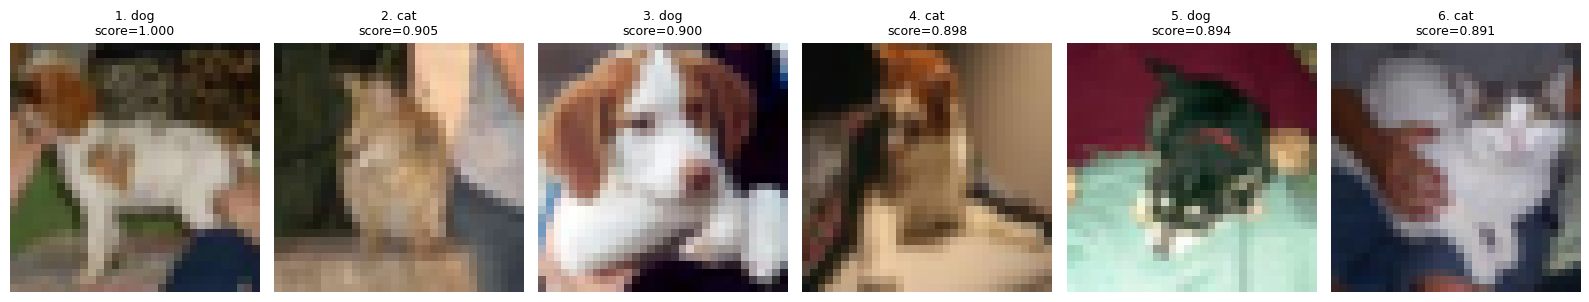

In [15]:

plot_results_grid(
    images=load_gallery_images(image_search_df),
    titles=[
        f"{row.rank}. {row.class_name}\nscore={row.score:.3f}"
        for row in image_search_df.itertuples()
    ],
    cols=6,
    figsize=(16, 4),
)


## 10. Ограничения CLIP-поиска на малом датасете

Даже на такой компактной галерее уже видны важные ограничения:

- если изображения слишком маленькие или шумные, retrieval становится менее устойчивым;
- слишком общие запросы вроде `an animal` дают размазанную выдачу;
- близкие по визуальному паттерну классы могут путаться;
- для узких предметных областей понадобится другой датасет и, возможно, адаптация модели;
- на больших коллекциях нужен уже не просто тензор в памяти, а индексатор уровня FAISS или векторной БД.

То есть текущий ноутбук показывает **правильную базовую механику**,  
но в реальном проекте её обычно масштабируют дополнительной инфраструктурой.


## 11. Итоги

В этом ноутбуке мы:

- подготовили локальную галерею изображений;
- посчитали для неё CLIP embeddings;
- реализовали text-to-image retrieval;
- сравнили разные формулировки запросов;
- собрали батчевую таблицу результатов;
- оценили retrieval через `Recall@1 / Recall@3 / Recall@5`;
- добавили image-to-image поиск.

Это уже полноценный учебный baseline для мультимодального поиска.


## Задания для самостоятельной работы

1. Замените учебную галерею на собственную папку с изображениями.
2. Проверьте, как retrieval меняется при более длинных и более коротких запросах.
3. Добавьте несколько альтернативных prompt-шаблонов на один класс и сравните качество.
4. Попробуйте сохранить embeddings на диск и загружать их без повторной индексации.
5. Подумайте, когда достаточно такого простого CLIP-поиска, а когда уже нужен FAISS или векторная БД.
